# Scenario-based forecasting with _SHAPER_

The _SHAPER_ allows you to create scenario-based forecasts by defining how covariates (influencing variables) evolve in the future. You can generate forecasts for high, low, and custom scenarios to understand the range of possible outcomes.

If you are using _EXPERT_ for the first time, we recommend that you begin with [Getting Started](getting_started.ipynb). For a general introduction to covariates, see [Forecasting with covariates](forecast_with_covariates.ipynb).

In [1]:
import time
from futureexpert import (DataDefinition,
                          ExpertClient,
                          FileSpecification,
                          TsCreationConfig,
                          checkin)

client = ExpertClient()

INFO:futureexpert.expert_client:Successfully logged in to futureEXPERT.


## Check in the actuals time series

First, upload your data to the _future_ platform. You can do this using the `check_in_time_series` method. For further information how to upload your data, check the coresponding [check-in notebook](checkin_configuration_options.ipynb)

In [2]:
actuals_version_id = client.check_in_time_series(raw_data_source='../example_data/ts_bicycle_roentgenring_20260131.csv',
                                                 data_definition=DataDefinition(date_column=checkin.DateColumn(name='date', format='%Y-%m-%d'),
                                                                                value_columns=[checkin.ValueColumn(name='value')]),
                                                 config_ts_creation=TsCreationConfig(time_granularity='daily',
                                                                                     start_date="2021-01-01",
                                                                                     value_columns_to_save=['value']),
                                                 file_specification=FileSpecification(delimiter=',', decimal='.'))

## Check in the covariate time series

Upload the covariates that serve as influencing variables for the forecast. In this example, we use temperature data.

In [3]:
covariate_version_id = client.check_in_time_series(raw_data_source='../example_data/temperatur.csv',
                                                   data_definition=DataDefinition(remove_columns=[0],
                                                                                  date_column=checkin.DateColumn(
                                                       name='date', format='%Y-%m-%d'),
                                                       value_columns=[
                                                       checkin.ValueColumn(name='value')],
                                                       group_columns=[checkin.GroupColumn(name='name')]),
                                                   config_ts_creation=TsCreationConfig(time_granularity='daily',
                                                                                       start_date="2021-01-01",
                                                                                       grouping_level=['name'],
                                                                                       value_columns_to_save=['value']),
                                                   file_specification=FileSpecification(delimiter=',', decimal='.'))

## Create scenario values

Use `create_scenario_values` to generate high and low scenario projections for the covariates. The method returns a configuration object containing the actuals, covariates, and their scenario projections.

You need to specify:
- The version ID and name of the actuals time series
- The version IDs of the covariate time series
- A list of `CovariateRef` objects specifying covariate names and their lags
- The forecast horizon

In [4]:
from futureexpert.shaper import ScenarioValuesConfig
from futureexpert.shared_models import CovariateRef

config = ScenarioValuesConfig(actuals_version=actuals_version_id,
                              actuals_name='value',
                              covariate_versions=[covariate_version_id],
                              covariates=[CovariateRef(
                                  name='value-Temperatur (täglicher Maximalwert; Würzburg)', lag=0)],
                              fc_horizon=10)

shaper_config = client.create_scenario_values(config)

## Inspect and customize scenarios

You can inspect the generated scenario values and visualize them. Use `plot_scenario` to review the high and low projections for each covariate.

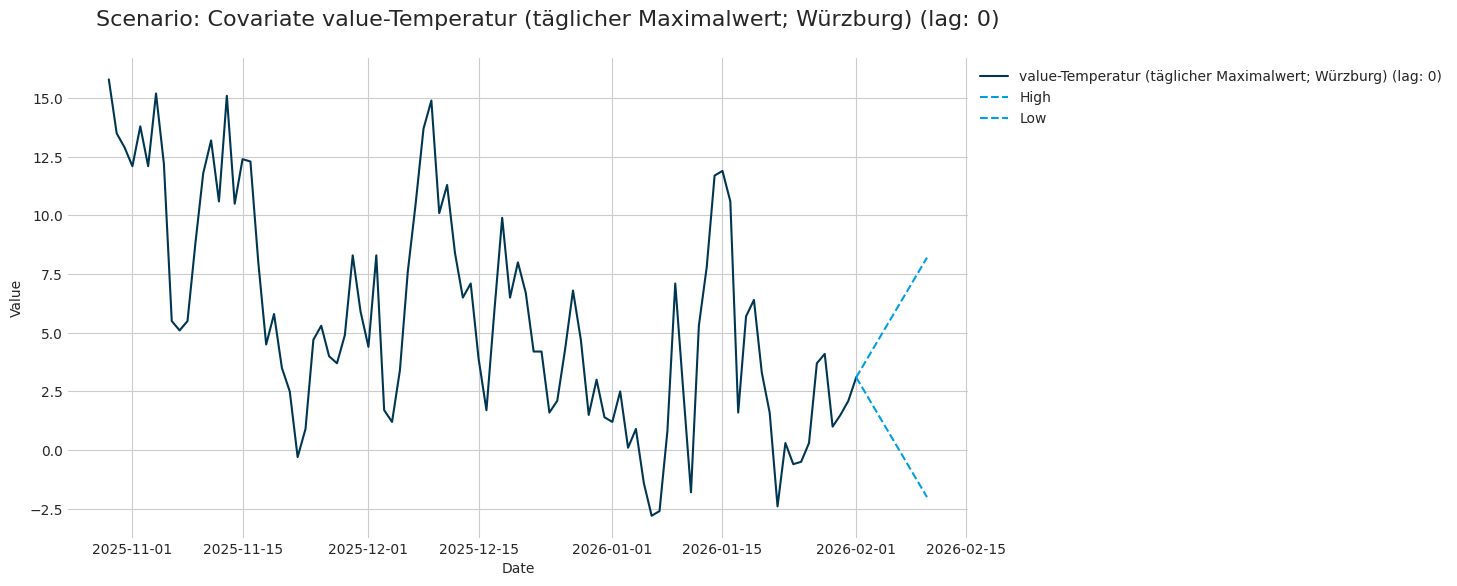

In [5]:
#look at scenarios and add custom values
from futureexpert import plot

for scenario in shaper_config.scenarios:
    plot.plot_scenario(scenario, plot_last_x_data_points_only=96)

Optionally, you can add custom scenario values using `add_custom_values` to define your own projection for a covariate.

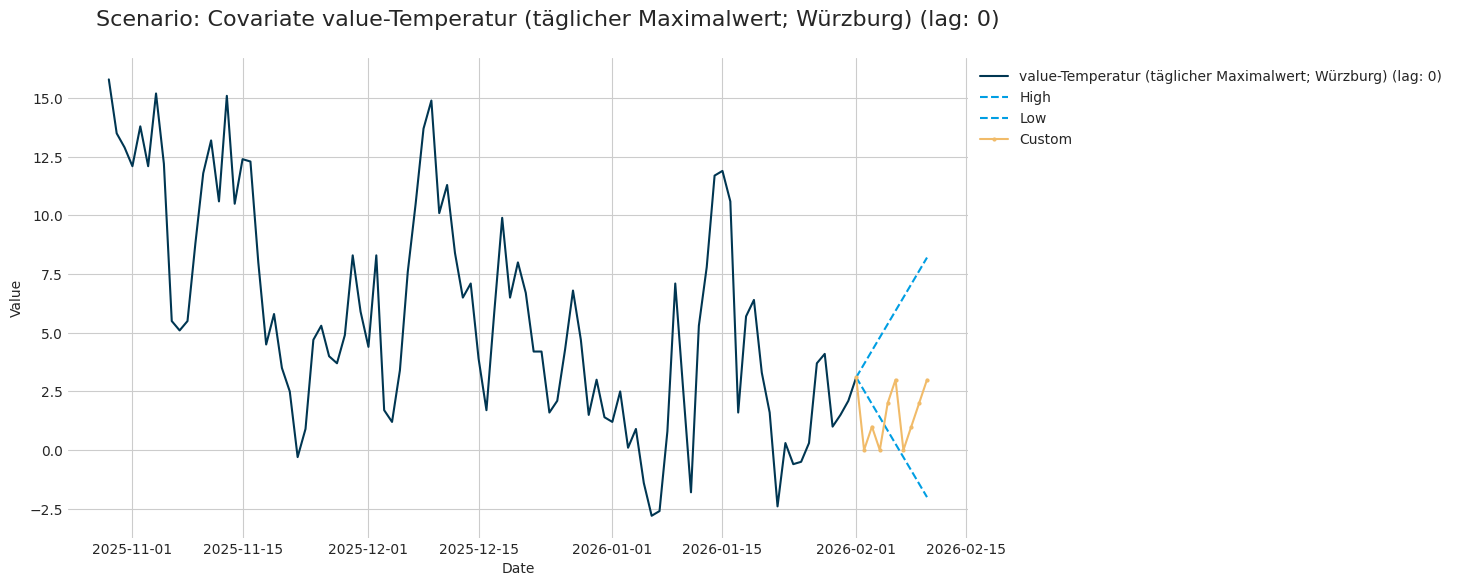

In [6]:
shaper_config.scenarios[0].add_custom_values([0,1,0,2,3,0,1,2,3])

# plot again with custom scenario
for scenario in shaper_config.scenarios:
    plot.plot_scenario(scenario, plot_last_x_data_points_only=96)

## Start the scenario forecast

Submit the scenario configuration to start the _SHAPER_ forecast. This triggers an asynchronous computation on the _future_ platform.

In [7]:
# start shaper
shaper_identifier = client.start_scenario_forecast(shaper_config)

INFO:futureexpert.expert_client:Report created with ID 184699. Shaping scenarios...


## Retrieve and visualize results

Once the computation is finished, retrieve the results and visualize them using `plot_shaper_results`. The plot shows the actuals alongside the forecast for each scenario (high, low, and custom if defined), including prediction intervals.

In [8]:
# Watch the current status of the forecasting report
while not (current_status := client.get_report_status(id=shaper_identifier)).is_finished:
    time.sleep(30)  # Wait between status requests
current_status.print()

Status of report "SHAPER for value for forecast horizon 10" of type "shaper":
 100 % are finished 
 1 runs requested for calculation 
 1 runs finished 
 0 runs without evaluation 
 0 runs ran into an error


In [9]:
# get shaper results
result = client.get_shaper_results(id=shaper_identifier)

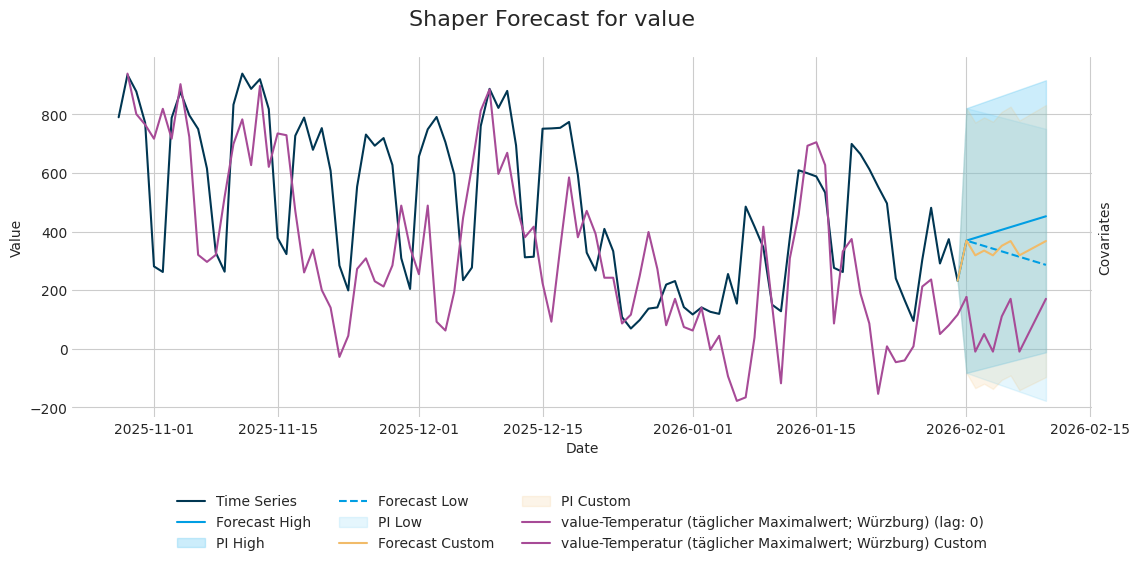

In [10]:
from futureexpert import plot

plot.plot_shaper_results(result, plot_last_x_data_points_only=96)